# Structural Equation Modeling (SEM) - Gogoro Customer Study

This notebook follows the SEM analysis pipeline from the mind map:

| Step | Analysis |
|------|----------|
| 1 | Data Cleaning (Missing Values, Outliers, Normality, Descriptive Stats) |
| 2 | Reliability (Cronbach's Alpha) |
| 3 | Validity - Exploratory Factor Analysis (Discriminant & Convergent) |
| 4 | Measurement Model - Confirmatory Factor Analysis (CFA) |
| 5 | Correlation Analysis & Multicollinearity |
| 6 | Structural Model (Path Analysis, Mediator Effect, Moderator Effect) |

**Constructs**: Functionality, Usability, Price, Brand → **Satisfaction** → **Loyalty**

**Dataset**: Gogoro electric scooter customer survey (N = 208)

### Setup: Load Libraries
Imports all Python packages needed for the analysis:
- `pandas` / `numpy` - data manipulation
- `matplotlib` / `seaborn` - visualisation
- `scipy` / `statsmodels` - statistical tests and regression

In [1]:
# Install required packages if needed
# !pip install semopy factor-analyzer pingouin -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


**How to read this output**: If you see "Libraries loaded." the environment is ready. If an ImportError appears, uncomment the pip install line at the top of the cell and re-run.

### Load Dataset & Define Constructs
Reads the Gogoro customer survey CSV and maps each **latent construct** to its **observed indicator items**.
This dictionary (`constructs`) drives all subsequent analyses - from reliability testing through SEM.

In [2]:
df = pd.read_csv('gogoro_data.csv')

# Encode Gender: Female = 0, Male = 1
df['Gender_enc'] = (df['Gender'] == 'Male').astype(int)

# Map each latent construct to its observed indicator items
constructs = {
    'Functionality': ['FS1',  'FS2',  'FS3',  'FS4',  'FS5'],
    'Usability':     ['US1',  'US2',  'US3',  'US4',  'US5'],
    'Design':        ['DS1',  'DS2',  'DS3',  'DS4'],
    'Price':         ['PS1',  'PS2',  'PS3',  'PS4'],
    'BrandImage':    ['BIS1', 'BIS2', 'BIS3', 'BIS4', 'BIS5'],
    'Satisfaction':  ['CSO1', 'CSO2', 'CSO3', 'CSO4', 'CSO5'],
    'Loyalty':       ['CLS1', 'CLS2', 'CLS3', 'CLS4']
}

item_cols       = [col for cols in constructs.values() for col in cols]
construct_names = list(constructs.keys())

print(f'Shape: {df.shape}')
df.head()

Shape: (208, 47)


,Respondent_ID,Gender,Age_Group,Income_TWD,Period_of_Use,Student_Status,FS1,FS2,FS3,FS4,...,CSO1,CSO2,CSO3,CSO4,CSO5,CLS1,CLS2,CLS3,CLS4,Gender_enc
0,R001,Female,23-28,"Above 50,001",Less than 1 Year,No,4,4,4,3,...,5,6,5,5,5,4,5,5,4,0
1,R002,Female,18-22,"25,001-30,000",2 Years,No,5,4,4,5,...,4,4,5,3,5,4,4,5,6,0
2,R003,Female,18-22,"25,001-30,000",1 Year,Yes,5,6,5,6,...,4,4,4,2,4,5,5,4,5,0
3,R004,Male,23-28,"Above 50,001",Less than 1 Year,No,4,3,3,4,...,4,3,3,3,4,5,4,5,4,1
4,R005,Male,29-33,"Above 50,001",2 Years,No,4,4,5,5,...,5,4,4,3,6,5,5,5,5,1


**How to read this output**: Confirm the shape (rows x columns) matches the expected sample size and number of variables. The first five rows let you verify that column names and values look correct before any analysis begins.

---
## Step 1: Data Cleaning

### 1a. Missing Value Check
Counts missing entries per scale item. Missing data can introduce bias if not handled.
We report the count and percentage of missing values before proceeding.

In [3]:
# --- 1a. Missing Values ---
print('=== Missing Values ===')
missing = df[item_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent (%)': missing_pct})

if missing_df['Count'].sum() == 0:
    print('No missing values found in scale items.')
else:
    print(missing_df[missing_df['Count'] > 0])

=== Missing Values ===
No missing values found in scale items.


**How to read this output**: If all counts show 0, the data is complete and you can proceed. If missing values are found, decide whether to remove those rows (listwise deletion) or impute values before running factor analysis or SEM.

### 1b. Outlier Detection
Standardises each item to z-scores and flags rows with |z| > 3 as extreme outliers.
Box plots visualise the score distribution across all items within each construct.

=== Outlier Detection (|z-score| > 3) ===
Outlier rows: 8 (3.8%)


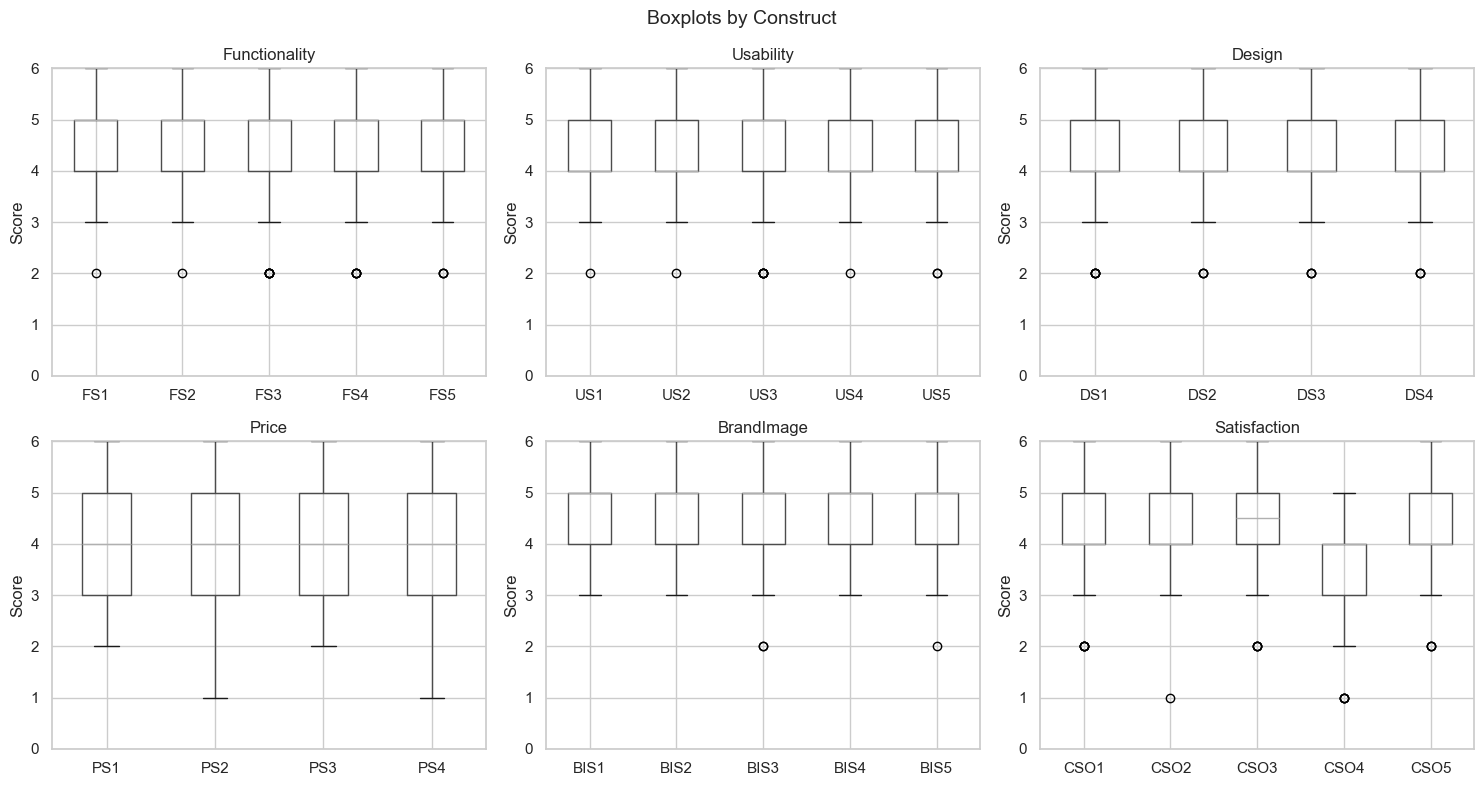

In [4]:
# --- 1b. Outlier Detection ---
print('=== Outlier Detection (|z-score| > 3) ===')
z_scores = np.abs(stats.zscore(df[item_cols].dropna()))
outlier_mask = (z_scores > 3).any(axis=1)
print(f'Outlier rows: {outlier_mask.sum()} ({outlier_mask.mean()*100:.1f}%)')

# Boxplots by construct
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, cols) in zip(axes.flatten(), constructs.items()):
    df[cols].boxplot(ax=ax)
    ax.set_title(name)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 6)
plt.suptitle('Boxplots by Construct', fontsize=14)
plt.tight_layout()
plt.show()

**How to read this output**: The count of flagged rows tells you how many respondents gave extreme responses on at least one item. A small proportion (below 5%) is typical and usually acceptable. In the boxplots, points beyond the whiskers are potential outliers - inspect them individually before deciding to remove or retain.

### 1c. Normality Test - Shapiro-Wilk

Tests whether each item follows a normal (bell-curve) distribution. SEM's Maximum Likelihood estimator assumes normality, so this check is done before modelling.

**Null Hypothesis (H0):** The data is normally distributed.

**Research Hypothesis (H1):** The data is not normally distributed.

**p-value:** The probability of observing the data assuming H0 is true. A small p-value means the data departs significantly from normality.

**Preferred p-value:** p > 0.05 - we want to retain H0, meaning the normality assumption holds. Mild violations are acceptable when N >= 200, as Maximum Likelihood estimation is robust to slight non-normality.

In [18]:
# --- 1c. Normality Test (Shapiro-Wilk) ---
print('=== Normality Test - Shapiro-Wilk ===')
norm_results = []
for col in item_cols:
    stat, p = shapiro(df[col].dropna())
    norm_results.append({
        'Item': col, 'W': round(stat, 4), 'p-value': round(p, 4),
        'Normal (p>0.05)': 'Yes' if p > 0.05 else 'No'
    })
norm_df = pd.DataFrame(norm_results)
print(norm_df.to_string(index=False))

# Summary counts
n_total  = len(norm_df)
n_pass   = (norm_df['Normal (p>0.05)'] == 'Yes').sum()
n_fail   = n_total - n_pass

print(f'\n--- Normality Summary ---')
print(f'  Total items : {n_total}')
print(f'  Passed (Normal)     : {n_pass}  ({n_pass/n_total*100:.1f}%)')
print(f'  Failed (Non-Normal) : {n_fail}  ({n_fail/n_total*100:.1f}%)')
print('\nNote: Mild non-normality is acceptable for ML estimation with N > 200.')



=== Normality Test - Shapiro-Wilk ===
Item      W  p-value Normal (p>0.05)
 FS1 0.8868      0.0              No
 FS2 0.8754      0.0              No
 FS3 0.8964      0.0              No
 FS4 0.8935      0.0              No
 FS5 0.8633      0.0              No
 US1 0.8834      0.0              No
 US2 0.8843      0.0              No
 US3 0.8986      0.0              No
 US4 0.8840      0.0              No
 US5 0.8892      0.0              No
 DS1 0.8884      0.0              No
 DS2 0.8928      0.0              No
 DS3 0.8953      0.0              No
 DS4 0.8909      0.0              No
 PS1 0.8926      0.0              No
 PS2 0.9059      0.0              No
 PS3 0.8986      0.0              No
 PS4 0.9066      0.0              No
BIS1 0.8667      0.0              No
BIS2 0.8623      0.0              No
BIS3 0.8730      0.0              No
BIS4 0.8607      0.0              No
BIS5 0.8807      0.0              No
CSO1 0.8834      0.0              No
CSO2 0.8747      0.0              No


**How to read this output**: Each item's p-value indicates whether its distribution is normal.

### 1d. Descriptive Statistics
Summarises the distribution of each scale item (Mean, SD, Min, Max, Skewness, Kurtosis).

Key thresholds for non-normality:
- **|Skewness| > 2** → severe asymmetry
- **|Kurtosis| > 7** → severely peaked or flat distribution

In [6]:
# --- 1d. Descriptive Statistics ---

# Categorical demographic variables
demo_cat = ['Gender', 'Age_Group', 'Income_TWD', 'Period_of_Use', 'Student_Status']
print('=== Demographic Variables ===')
for col in demo_cat:
    counts = df[col].value_counts().sort_index()
    print(f'\n{col}:')
    for val, cnt in counts.items():
        print(f'  {val:25s}: {cnt:3d}  ({cnt/len(df)*100:.1f}%)')

# Scale items
print('\n=== Scale Items - Descriptive Statistics (Scale: 1–6) ===')
desc = df[item_cols].describe().T[['mean', 'std', 'min', 'max']]
desc.columns = ['Mean', 'SD', 'Min', 'Max']
desc['Skewness'] = df[item_cols].skew().round(3)
desc['Kurtosis'] = df[item_cols].kurtosis().round(3)
print(desc.round(3))

=== Demographic Variables ===

Gender:
  Female                   :  87  (41.8%)
  Male                     : 121  (58.2%)

Age_Group:
  18-22                    :  47  (22.6%)
  23-28                    :  48  (23.1%)
  29-33                    :  34  (16.3%)
  34-38                    :  28  (13.5%)
  39-43                    :  30  (14.4%)
  44-48                    :  11  (5.3%)
  49-53                    :   8  (3.8%)
  Above 53                 :   2  (1.0%)

Income_TWD:
  20,001-25,000            :  19  (9.1%)
  25,001-30,000            :  44  (21.2%)
  30,001-35,000            :  36  (17.3%)
  35,001-40,000            :  21  (10.1%)
  40,001-50,000            :  20  (9.6%)
  Above 50,001             :  33  (15.9%)
  Under 20,000             :  35  (16.8%)

Period_of_Use:
  1 Year                   :  41  (19.7%)
  2 Years                  :  28  (13.5%)
  3 Years                  :   5  (2.4%)
  Less than 1 Year         : 134  (64.4%)

Student_Status:
  No                       

**How to read this output**:

**Demographic section** - Age and Ownership_Months show continuous descriptives (mean, SD, min, median, max). The gender breakdown shows how many respondents are female (0) and male (1), giving a picture of the sample composition.

**Scale items section** - Mean values near the midpoint of the rating scale (e.g., 3 on a 5-point scale) indicate balanced responses. Skewness outside the range -1 to 1 suggests asymmetry; kurtosis outside -3 to 3 suggests heavier or lighter tails than a normal distribution. Items with extreme values may affect model estimation and should be noted.

---
## Step 2: Reliability - Cronbach's Alpha


### Cronbach's Alpha - Internal Consistency
Measures how strongly the items within each construct correlate with each other.
This is **not a hypothesis test** - it is evaluated against fixed benchmarks:

| α Value | Interpretation |
|---------|----------------|
| ≥ 0.90  | Excellent       |
| ≥ 0.80  | Good            |
| ≥ 0.70  | Acceptable      |
| < 0.70  | Poor - consider revising the scale |

In [7]:
def cronbach_alpha(data):
    """Compute Cronbach's Alpha from a DataFrame of items."""
    k = data.shape[1]
    item_var = data.var(axis=0, ddof=1)
    total_var = data.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

print("=== Cronbach's Alpha by Construct ===")
alpha_rows = []
for name, cols in constructs.items():
    alpha = cronbach_alpha(df[cols].dropna())
    if alpha >= 0.9:   interp = 'Excellent'
    elif alpha >= 0.8: interp = 'Good'
    elif alpha >= 0.7: interp = 'Acceptable'
    else:              interp = 'Poor'
    alpha_rows.append({'Construct': name, 'Items': len(cols),
                        "Cronbach's α": round(alpha, 3), 'Interpretation': interp})

alpha_df = pd.DataFrame(alpha_rows)
print(alpha_df.to_string(index=False))

=== Cronbach's Alpha by Construct ===
    Construct  Items  Cronbach's α Interpretation
Functionality      5         0.887           Good
    Usability      5         0.867           Good
       Design      4         0.928      Excellent
        Price      4         0.931      Excellent
   BrandImage      5         0.897           Good
 Satisfaction      5         0.924      Excellent
      Loyalty      4         0.910      Excellent


**How to read this output**: Each row shows Cronbach's alpha for one construct. Values of 0.70 or above indicate acceptable internal consistency - the items in that construct are measuring the same underlying concept reliably. Values below 0.70 suggest the construct should be revised before proceeding to factor analysis.

---
## Step 3: Validity - Exploratory Factor Analysis (EFA)

### Bartlett's Test of Sphericity

**What it tests:** Are the variables correlated with each other at all?

- **H0:** The correlation matrix is an identity matrix (all variables are uncorrelated — factor analysis would be pointless)
- **H1:** The correlation matrix is NOT an identity matrix (variables share common variance — factor analysis is meaningful)

| Result | Meaning |
|--------|---------|
| chi2 = 4868.06 | Very large — strong evidence of correlation among items |
| p = 0.0000 | Reject H0 |

**Conclusion:** The 33 items are significantly intercorrelated. Factor analysis is appropriate.

---

### KMO (Kaiser-Meyer-Olkin)

**What it tests:** Are the correlations between items due to underlying factors, or just noise?

- Compares partial correlations vs. simple correlations
- Range: 0 to 1 — higher is better

| KMO Value | Interpretation |
|-----------|---------------|
| ≥ 0.90 | Marvelous |
| 0.80–0.89 | Meritorious |
| 0.70–0.79 | Middling |
| 0.60–0.69 | Mediocre |
| < 0.60 | Unacceptable |

**Your result: KMO = 0.931 → "Marvelous"**

**Convergent Validity**: Primary factor loadings > 0.5
**Discriminant Validity**: Cross-loadings < 0.3; each item loads clearly on one factor

### EFA Pre-Tests: Bartlett's Test & KMO

Two checks confirm that factor analysis is appropriate for the data.

**Bartlett's Test of Sphericity**

|  | |
|---|---|
| **H₀** | All items are uncorrelated (correlation matrix = identity matrix) |
| **H₁** | Items share enough correlation to extract meaningful factors |

**p-value**: Probability of the observed inter-item correlations occurring by chance if items were truly independent.
**Preferred for researchers**: p **< 0.05** - reject H₀ to confirm that sufficient shared variance exists for factor extraction.

---

**KMO (Kaiser-Meyer-Olkin)** - Not a hypothesis test. Measures sampling adequacy (0–1):

| KMO    | Adequacy       |
|--------|----------------|
| ≥ 0.80 | Meritorious    |
| ≥ 0.60 | Adequate       |
| < 0.60 | Inadequate - factor analysis unreliable |

In [20]:
# Compatibility fix: patch check_array directly inside factor_analyzer's namespace
import factor_analyzer.factor_analyzer as _faf
import sklearn.utils.validation as _suv
import importlib, inspect as _inspect

importlib.reload(_suv)
_real = _suv.check_array
if 'force_all_finite' not in _inspect.signature(_real).parameters:
    def _make(fn):
        def _compat(*args, **kwargs):
            if 'force_all_finite' in kwargs:
                kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
            return fn(*args, **kwargs)
        return _compat
    _faf.check_array = _make(_real)

from factor_analyzer import FactorAnalyzer
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# Pre-tests
chi2_val, p_val = calculate_bartlett_sphericity(df[item_cols].dropna())
_, kmo_model   = calculate_kmo(df[item_cols].dropna())

print(f"Bartlett's Test of Sphericity: chi2 = {chi2_val:.2f}, p = {p_val:.4f}")
print(f"KMO Measure of Sampling Adequacy: {kmo_model:.3f}",
      '(Adequate)' if kmo_model >= 0.6 else '(Inadequate)')

# Fit EFA - 7 factors (one per construct), varimax rotation
fa = FactorAnalyzer(n_factors=7, rotation='varimax', method='minres')
fa.fit(df[item_cols].dropna())

loading_df = pd.DataFrame(
    fa.loadings_,
    index=item_cols,
    columns=[f'F{i+1}' for i in range(7)]
).round(3)

print('\n=== EFA Factor Loadings (Varimax) ===')
print(loading_df)

Bartlett's Test of Sphericity: chi2 = 4868.06, p = 0.0000
KMO Measure of Sampling Adequacy: 0.931 (Adequate)

=== EFA Factor Loadings (Varimax) ===
         F1     F2     F3     F4     F5     F6     F7
FS1   0.150  0.225  0.144  0.746  0.094  0.102  0.045
FS2   0.266  0.232  0.140  0.693  0.039  0.140 -0.022
FS3   0.210  0.136  0.133  0.717  0.081  0.140  0.057
FS4   0.194  0.211  0.082  0.672  0.039  0.186  0.026
FS5   0.208  0.067  0.093  0.709  0.100  0.209  0.087
US1   0.190  0.112  0.083  0.215  0.112  0.683  0.023
US2   0.186  0.154  0.083  0.070  0.029  0.678 -0.033
US3   0.091  0.279  0.043  0.195  0.093  0.678  0.043
US4   0.110  0.166  0.012  0.125  0.041  0.716  0.117
US5   0.172  0.253  0.159  0.143  0.080  0.705  0.055
DS1   0.054  0.051  0.009  0.053  0.849  0.131  0.034
DS2   0.048  0.175 -0.007  0.007  0.835  0.054 -0.003
DS3   0.114  0.188  0.045  0.095  0.868  0.024  0.003
DS4   0.060  0.075  0.049  0.140  0.877  0.083  0.022
PS1   0.175  0.072  0.842  0.169  0.049  0

**How to read this output**: Bartlett's test should be significant (p < 0.05), confirming that the items share enough correlation for factor analysis. The KMO value should be 0.60 or above; values above 0.80 are ideal. In the loading table, each item should load strongly (above 0.50) on one factor and weakly (below 0.30) on all others. Clear loading patterns support the proposed construct structure.

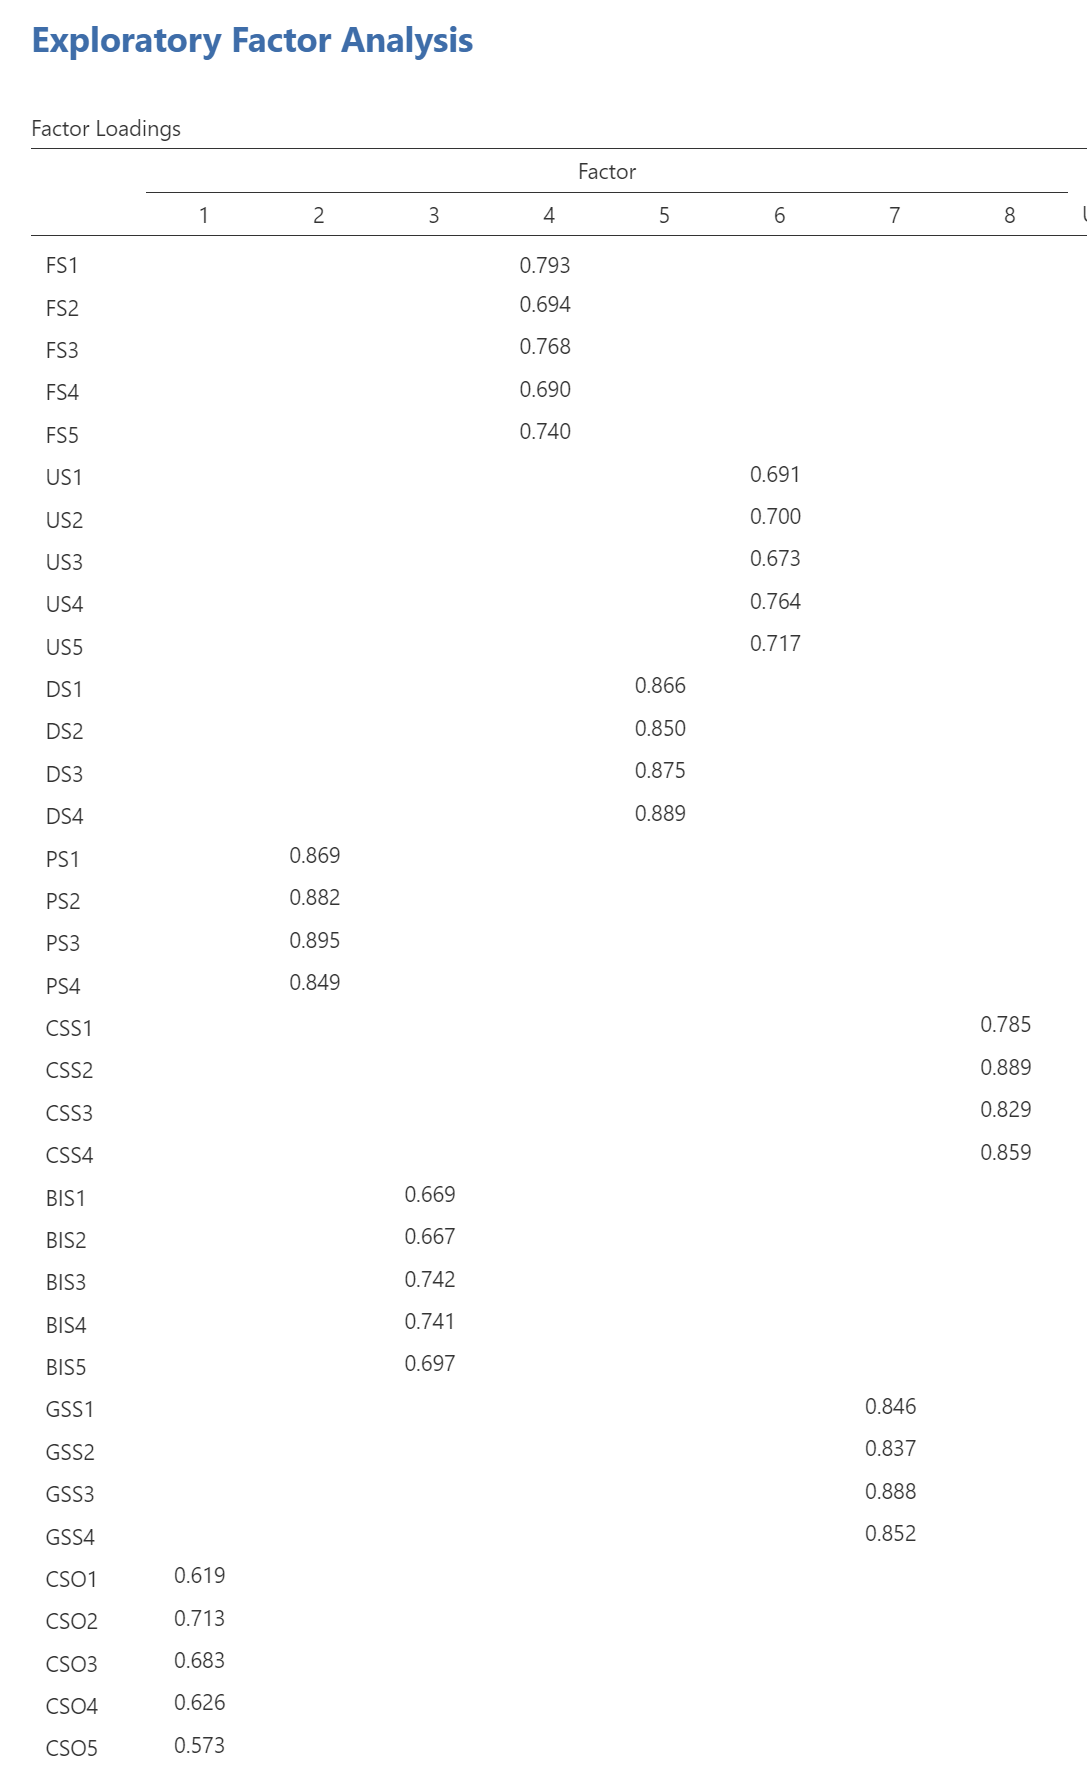
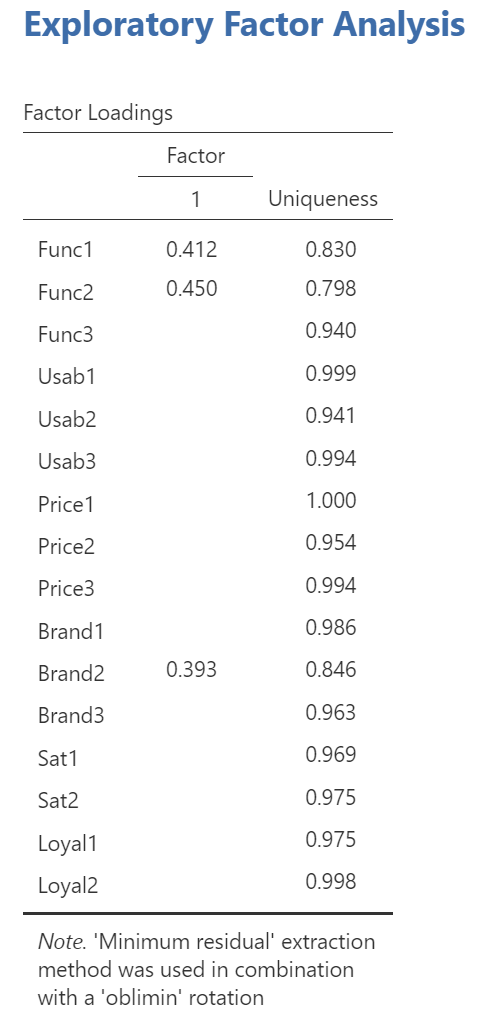

### EFA: Convergent & Discriminant Validity

Evaluates whether items behave as theory predicts:
- **Convergent validity**: Primary factor loading > 0.5 - items strongly reflect their intended construct
- **Discriminant validity**: Gap between primary and second-highest loading ≥ 0.2 - items are not ambiguous across factors

In [ ]:
# Convergent validity - primary loadings
print('=== Convergent Validity (Primary Loading > 0.5) ===')
for name, cols in constructs.items():
    max_loads = loading_df.loc[cols].abs().max(axis=1)
    print(f'\n{name}:')
    for item, val in max_loads.items():
        flag = 'OK' if val >= 0.5 else 'FAIL'
        print(f'  {item}: {val:.3f}  [{flag}]')

# Discriminant validity - cross-loadings
print('\n=== Discriminant Validity (Primary vs 2nd-highest loading) ===')
for name, cols in constructs.items():
    for item in cols:
        sorted_loads = loading_df.loc[item].abs().sort_values(ascending=False)
        diff = sorted_loads.iloc[0] - sorted_loads.iloc[1]
        flag = 'OK' if diff >= 0.2 else 'CHECK'
        print(f'  {item}: Primary={sorted_loads.iloc[0]:.3f}  2nd={sorted_loads.iloc[1]:.3f}  Diff={diff:.3f}  [{flag}]')

# Variance explained
var_exp = fa.get_factor_variance()
ve_df = pd.DataFrame(var_exp, index=['SS Loadings', 'Proportion Var', 'Cumulative Var'],
                     columns=[f'F{i+1}' for i in range(7)]).round(3)
print('\n=== Variance Explained ===')
print(ve_df)

=== Convergent Validity (Primary Loading > 0.5) ===

Functionality:
  FS1: 0.746  [OK]
  FS2: 0.693  [OK]
  FS3: 0.717  [OK]
  FS4: 0.672  [OK]
  FS5: 0.709  [OK]

Usability:
  US1: 0.683  [OK]
  US2: 0.678  [OK]
  US3: 0.678  [OK]
  US4: 0.716  [OK]
  US5: 0.705  [OK]

Design:
  DS1: 0.849  [OK]
  DS2: 0.835  [OK]
  DS3: 0.868  [OK]
  DS4: 0.877  [OK]

Price:
  PS1: 0.842  [OK]
  PS2: 0.848  [OK]
  PS3: 0.868  [OK]
  PS4: 0.817  [OK]

BrandImage:
  BIS1: 0.675  [OK]
  BIS2: 0.685  [OK]
  BIS3: 0.748  [OK]
  BIS4: 0.726  [OK]
  BIS5: 0.703  [OK]

Satisfaction:
  CSO1: 0.589  [OK]
  CSO2: 0.638  [OK]
  CSO3: 0.631  [OK]
  CSO4: 0.559  [OK]
  CSO5: 0.541  [OK]

Loyalty:
  CLS1: 0.817  [OK]
  CLS2: 0.752  [OK]
  CLS3: 0.818  [OK]
  CLS4: 0.773  [OK]

=== Discriminant Validity (Primary vs 2nd-highest loading) ===
  FS1: Primary=0.746  2nd=0.225  Diff=0.521  [OK]
  FS2: Primary=0.693  2nd=0.266  Diff=0.427  [OK]
  FS3: Primary=0.717  2nd=0.210  Diff=0.507  [OK]
  FS4: Primary=0.672  2nd=0.2

**How to read this output**: For convergent validity, items marked OK have a primary loading above 0.50 - they adequately represent their construct. For discriminant validity, items marked OK have a clear separation between their primary and secondary loadings, meaning they are not ambiguous across factors. Items marked FAIL or CHECK should be reviewed and may need to be revised or removed.

---
## Step 4: Measurement Model - Confirmatory Factor Analysis (CFA)

| Fit Index | Good Fit    |
|-----------|-------------|
| CFI / TLI | ≥ 0.95      |
| RMSEA     | ≤ 0.06      |
| SRMR      | ≤ 0.08      |
| χ²/df     | < 3.0       |

**AVE** > 0.5 → Convergent Validity  
**CR** > 0.7 → Construct Reliability

### CFA: Measurement Model Specification
Specifies the theory-driven factor structure and estimates all parameters simultaneously using **Maximum Likelihood (ML)**.
Unlike EFA, the loading pattern is pre-specified - making this a *confirmatory* test of the measurement theory.

In [10]:
import semopy

cfa_desc = '''
    Functionality =~ FS1  + FS2  + FS3  + FS4  + FS5
    Usability     =~ US1  + US2  + US3  + US4  + US5
    Design        =~ DS1  + DS2  + DS3  + DS4
    Price         =~ PS1  + PS2  + PS3  + PS4
    BrandImage    =~ BIS1 + BIS2 + BIS3 + BIS4 + BIS5
    Satisfaction  =~ CSO1 + CSO2 + CSO3 + CSO4 + CSO5
    Loyalty       =~ CLS1 + CLS2 + CLS3 + CLS4
'''

cfa_model = semopy.Model(cfa_desc)
cfa_model.fit(df[item_cols].dropna())

params = cfa_model.inspect(std_est=True)

# semopy: lval=item, rval=construct
load_rows = params[~params['lval'].isin(construct_names)]
loadings  = load_rows[['rval', 'lval', 'Estimate', 'Std. Err', 'z-value', 'p-value', 'Est. Std']].copy()
loadings.columns = ['Construct', 'Item', 'B', 'SE', 'z', 'p', 'beta*']

print('=== CFA Factor Loadings ===')
print(loadings.round(3).to_string(index=False))

=== CFA Factor Loadings ===
    Construct Item     B        SE          z    p  beta*
Functionality  FS1 1.000         -          -    -  0.808
Functionality  FS2 0.920   0.07276  12.639044  0.0  0.800
Functionality  FS3 1.042  0.083988  12.403826  0.0  0.789
Functionality  FS4 1.024  0.086411  11.845021  0.0  0.760
Functionality  FS5 0.853  0.071486  11.931585  0.0  0.765
    Usability  US1 1.000         -          -    -  0.745
    Usability  US2 1.059  0.107715   9.827096  0.0  0.705
    Usability  US3 1.164  0.108484  10.729101  0.0  0.768
    Usability  US4 1.011  0.097314  10.385923  0.0  0.744
    Usability  US5 1.100  0.097573  11.276762  0.0  0.807
       Design  DS1 1.000         -          -    -  0.857
       Design  DS2 1.011  0.064257  15.736357  0.0  0.850
       Design  DS3 1.101   0.06352  17.332893  0.0  0.898
       Design  DS4 1.046  0.061387  17.039772  0.0  0.889
        Price  PS1 1.000         -          -    -  0.884
        Price  PS2 1.056  0.059536  17.73354

**How to read this output**: The standardised estimate (beta*) shows how strongly each item reflects its latent construct on a 0 to 1 scale. Values above 0.50 are acceptable; above 0.70 is good. Items with p > 0.05 are not statistically significant and contribute little to the construct. A dash in the SE and p columns means the loading was fixed to 1 for model identification - that is normal for the first indicator of each construct.

### CFA Factor Loadings — How to Interpret

#### Columns
| Column | Meaning |
|--------|---------|
| **B** | Unstandardized loading (first item per construct fixed to 1.0 as reference) |
| **SE** | Standard error of B |
| **z** | z-statistic (B / SE) |
| **p** | p-value — all = 0.0, meaning all loadings are highly significant |
| **beta*** | **Standardized loading** — the one to focus on (range: –1 to 1) |

---

#### Part 1 — Factor Loadings (Construct → Items)

**Rule of thumb:** beta* ≥ 0.70 is strong; ≥ 0.50 is acceptable.

| Construct | Range of beta* | Assessment |
|-----------|---------------|------------|
| Functionality | 0.760 – 0.808 | Strong |
| Usability | 0.705 – 0.807 | Strong |
| Design | 0.850 – 0.898 | Very strong |
| Price | 0.855 – 0.902 | Very strong |
| BrandImage | 0.750 – 0.848 | Strong |
| Satisfaction | 0.782 – 0.868 | Strong |
| Loyalty | 0.834 – 0.867 | Strong |

**All items load significantly (p = 0.0) and strongly (beta* > 0.70) onto their intended constructs — good convergent validity.**

---

#### Part 2 — Error (Residual) Variances (Item → Itself)

The lower block (e.g., `BIS1 BIS1`, `FS1 FS1`) shows the **unique variance** not explained by the latent factor. These are expected and normal — every item has some measurement error. The beta* values here represent the error portion; lower is better.

---

#### Bottom Line

The CFA measurement model is **well-specified**:
- All standardized loadings exceed 0.70
- All are statistically significant (p < .001)
- Proceed to calculate **AVE and Composite Reliability** to confirm convergent validity

### CFA: Fit Indices, AVE & Composite Reliability

**χ² Goodness-of-Fit Test** (embedded in fit statistics)

|  | |
|---|---|
| **H₀** | Model-implied covariance matrix = observed covariance matrix (perfect fit) |
| **H₁** | There is a significant discrepancy between model and data |

**p-value**: Probability of the observed discrepancy occurring by chance if H₀ is true.
**Note**: For χ², **p > 0.05** would indicate good fit - but χ² inflates with large N (> 200). Rely on **CFI, RMSEA, and SRMR** as primary indices.

---

**AVE & CR** are not hypothesis tests - evaluated against thresholds:
- **AVE > 0.5** → Convergent validity confirmed
- **CR > 0.7** → Construct reliability confirmed

In [11]:
# Fit statistics
fit = semopy.calc_stats(cfa_model)
print('=== CFA Model Fit Statistics ===')
print(fit.T.rename(columns={0: 'Value'}).round(4))

# AVE and Composite Reliability
# semopy: lval=item, rval=construct → group by rval to get each construct's loadings
std_params = cfa_model.inspect(std_est=True)
load_df = std_params[~std_params['lval'].isin(construct_names)][['rval', 'lval', 'Est. Std']]

print('\n=== Convergent Validity: AVE and Composite Reliability ===')
ave_cr_rows = []
for name in construct_names:
    lam = load_df[load_df['rval'] == name]['Est. Std'].values
    lam_sq = lam ** 2
    ave = lam_sq.mean()
    cr  = lam.sum()**2 / (lam.sum()**2 + (1 - lam_sq).sum())
    ave_cr_rows.append({
        'Construct': name, 'AVE': round(ave, 3), 'CR': round(cr, 3),
        'AVE > 0.5': 'Yes' if ave > 0.5 else 'No',
        'CR > 0.7':  'Yes' if cr  > 0.7 else 'No'
    })
print(pd.DataFrame(ave_cr_rows).to_string(index=False))

=== CFA Model Fit Statistics ===
                   Value
DoF             443.0000
DoF Baseline    496.0000
chi2            435.7401
chi2 p-value      0.5882
chi2 Baseline  5179.3196
CFI               1.0016
GFI               0.9159
AGFI              0.9058
NFI               0.9159
TLI               1.0017
RMSEA             0.0000
AIC             165.8102
BIC             449.5009
LogLik            2.0949

=== Convergent Validity: AVE and Composite Reliability ===
    Construct   AVE    CR AVE > 0.5 CR > 0.7
Functionality 0.616 0.889       Yes      Yes
    Usability 0.570 0.869       Yes      Yes
       Design 0.764 0.928       Yes      Yes
        Price 0.773 0.932       Yes      Yes
   BrandImage 0.636 0.897       Yes      Yes
 Satisfaction 0.710 0.924       Yes      Yes
      Loyalty 0.719 0.911       Yes      Yes


**How to read this output**: For model fit, look for CFI and TLI above 0.95 and RMSEA below 0.06. A lower AIC and BIC indicate a more parsimonious model when comparing alternatives. For the validity table, AVE above 0.50 confirms convergent validity and CR above 0.70 confirms construct reliability. Constructs failing these thresholds have weak measurement and should be reconsidered before running the structural model.

### Convergent Validity: AVE and Composite Reliability

#### What These Measures Tell You

| Measure | Full Name | Question It Answers | Threshold |
|---------|-----------|---------------------|-----------|
| **AVE** | Average Variance Extracted | Do items explain more variance in the construct than measurement error does? | > 0.50 |
| **CR** | Composite Reliability | Do items consistently measure the same construct? | > 0.70 |

---

#### Your Results

| Construct | AVE | CR | Pass? |
|-----------|-----|-----|-------|
| Functionality | 0.616 | 0.889 | Yes / Yes |
| Usability | 0.570 | 0.869 | Yes / Yes |
| Design | 0.764 | 0.928 | Yes / Yes |
| Price | 0.773 | 0.932 | Yes / Yes |
| BrandImage | 0.636 | 0.897 | Yes / Yes |
| Satisfaction | 0.710 | 0.924 | Yes / Yes |
| Loyalty | 0.719 | 0.911 | Yes / Yes |

---

#### Interpretation

**AVE > 0.50** means each construct explains **more than half** of the variance in its items — signal outweighs noise.
- Weakest: Usability (0.570) — barely passes but still acceptable
- Strongest: Price (0.773) and Design (0.764) — items are very tightly defined

**CR > 0.70** means items within each construct are **internally consistent** — they reliably measure the same underlying concept.
- All CR values fall between 0.869–0.932, well above the threshold
- CR is preferred over Cronbach's alpha for SEM because it accounts for unequal item loadings

---

#### Bottom Line

**All 7 constructs demonstrate strong convergent validity.**
Items reliably and consistently measure their intended latent constructs.
Proceed to check **discriminant validity** (Fornell-Larcker criterion).

---
## Step 5: Correlation Analysis & Multicollinearity Check

- **Fornell-Larcker Criterion**: √AVE for each construct should exceed its correlations with other constructs
- **Multicollinearity**: r > 0.85 between constructs signals redundancy; VIF > 5 is a concern

### Correlation Matrix
Displays pairwise Pearson correlations between composite scores of all constructs. Serves two purposes:
1. **Relationship overview** - direction and magnitude of associations between constructs
2. **Discriminant validity check** - no two constructs should correlate near ±1.0

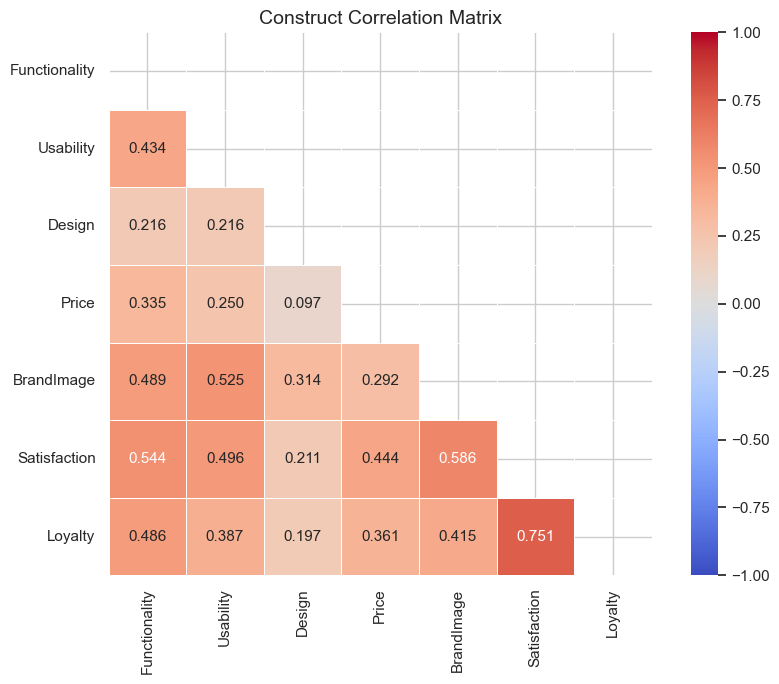

=== Correlation Matrix ===
               Functionality  Usability  Design  Price  BrandImage  \
Functionality          1.000      0.434   0.216  0.335       0.489   
Usability              0.434      1.000   0.216  0.250       0.525   
Design                 0.216      0.216   1.000  0.097       0.314   
Price                  0.335      0.250   0.097  1.000       0.292   
BrandImage             0.489      0.525   0.314  0.292       1.000   
Satisfaction           0.544      0.496   0.211  0.444       0.586   
Loyalty                0.486      0.387   0.197  0.361       0.415   

               Satisfaction  Loyalty  
Functionality         0.544    0.486  
Usability             0.496    0.387  
Design                0.211    0.197  
Price                 0.444    0.361  
BrandImage            0.586    0.415  
Satisfaction          1.000    0.751  
Loyalty               0.751    1.000  


In [12]:
# Compute composite scores (mean of indicators)
for name, cols in constructs.items():
    df[name] = df[cols].mean(axis=1)

corr_matrix = df[construct_names].corr().round(3)

# Heatmap
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, mask=mask,
            square=True, linewidths=0.5, annot_kws={'size': 11})
plt.title('Construct Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

print('=== Correlation Matrix ===')
print(corr_matrix)

**How to read this output**: The heatmap and matrix show pairwise correlations between all construct composite scores. Positive correlations between predictors and outcomes (Satisfaction, Loyalty) are expected. Correlations above 0.85 between any two predictors suggest those constructs may be too similar - this would raise a discriminant validity concern.

### Multicollinearity Check - Fornell-Larcker & VIF

**Fornell-Larcker Criterion**: √AVE for each construct must exceed its largest inter-construct correlation.
If not, two constructs are too similar - discriminant validity fails.

**VIF (Variance Inflation Factor)** - Not a hypothesis test. Quantifies predictor redundancy due to collinearity:

| VIF   | Status                                |
|-------|---------------------------------------|
| < 5   | No concern                            |
| 5–10  | Moderate - interpret with caution     |
| > 10  | Severe - remove or combine predictors |

In [13]:
# Fornell-Larcker Criterion
ave_vals = {r['Construct']: r['AVE'] for r in ave_cr_rows}
print('=== Fornell-Larcker Criterion (root-AVE vs. Inter-Construct Correlations) ===')
fl_rows = []
for name in construct_names:
    sqrt_ave = round(np.sqrt(ave_vals[name]), 3)
    max_corr = corr_matrix[name].drop(name).abs().max().round(3)
    fl_rows.append({'Construct': name, 'root-AVE': sqrt_ave,
                    'Max |r|': max_corr,
                    'Discriminant': 'Yes' if sqrt_ave > max_corr else 'No'})
print(pd.DataFrame(fl_rows).to_string(index=False))

# VIF for predictors of Satisfaction
print('\n=== Multicollinearity Check - VIF (Predictors of Satisfaction) ===')
predictors = ['Functionality', 'Usability', 'Design', 'Price', 'BrandImage']
X = df[predictors].dropna()
X_const = sm.add_constant(X)
vif_rows = [{'Predictor': c,
              'VIF': round(variance_inflation_factor(X_const.values, i+1), 3),
              'Status': 'OK' if variance_inflation_factor(X_const.values, i+1) < 5 else 'Warning'}
             for i, c in enumerate(predictors)]
print(pd.DataFrame(vif_rows).to_string(index=False))
print('VIF < 5: No issue | 5-10: Moderate | > 10: Severe multicollinearity')

=== Fornell-Larcker Criterion (root-AVE vs. Inter-Construct Correlations) ===
    Construct  root-AVE  Max |r| Discriminant
Functionality     0.785    0.544          Yes
    Usability     0.755    0.525          Yes
       Design     0.874    0.314          Yes
        Price     0.879    0.444          Yes
   BrandImage     0.797    0.586          Yes
 Satisfaction     0.843    0.751          Yes
      Loyalty     0.848    0.751          Yes

=== Multicollinearity Check - VIF (Predictors of Satisfaction) ===
    Predictor   VIF Status
Functionality 1.464     OK
    Usability 1.473     OK
       Design 1.118     OK
        Price 1.161     OK
   BrandImage 1.655     OK
VIF < 5: No issue | 5-10: Moderate | > 10: Severe multicollinearity


**How to read this output**: For the Fornell-Larcker criterion, each construct's root AVE (square root of AVE) should be larger than its highest correlation with any other construct. If not, discriminant validity fails for that construct. For VIF, all values should be below 5. Values above 5 indicate that two or more predictors are highly correlated, which inflates standard errors and makes path coefficients unreliable.

---
## Step 6: Structural Model

**Hypothesized Model**:
- Functionality, Usability, Price, Brand → **Satisfaction**
- Satisfaction → **Loyalty** (+ direct paths from predictors to test partial vs. full mediation)

### 6a. Path Analysis

### Structural Model: Path Analysis

Estimates all structural paths simultaneously while accounting for measurement error. Each path coefficient (β) is tested with a **z-test**:

|  | |
|---|---|
| **H₀** | Path coefficient = 0 (no relationship between constructs) |
| **H₁** | Path coefficient ≠ 0 (a significant directional relationship exists) |

**p-value**: Probability of observing a coefficient this large by chance if H₀ is true.
**Preferred for researchers**: **p < 0.05** - reject H₀ to confirm that one construct significantly predicts another.

| Code | Significance |
|------|-------------|
| `***` | p < 0.001   |
| `**`  | p < 0.01    |
| `*`   | p < 0.05    |
| `ns`  | p ≥ 0.05    |

In [14]:
sem_desc = '''
    Functionality =~ FS1  + FS2  + FS3  + FS4  + FS5
    Usability     =~ US1  + US2  + US3  + US4  + US5
    Design        =~ DS1  + DS2  + DS3  + DS4
    Price         =~ PS1  + PS2  + PS3  + PS4
    BrandImage    =~ BIS1 + BIS2 + BIS3 + BIS4 + BIS5
    Satisfaction  =~ CSO1 + CSO2 + CSO3 + CSO4 + CSO5
    Loyalty       =~ CLS1 + CLS2 + CLS3 + CLS4

    Satisfaction ~ Functionality + Usability + Design + Price + BrandImage
    Loyalty      ~ Satisfaction  + Functionality + Usability + Design + Price + BrandImage
'''

sem_model = semopy.Model(sem_desc)
sem_model.fit(df[item_cols].dropna())

sem_params = sem_model.inspect(std_est=True)

struct = sem_params[
    sem_params['lval'].isin(construct_names) &
    sem_params['rval'].isin(construct_names)
][['lval', 'rval', 'Estimate', 'Std. Err', 'z-value', 'p-value', 'Est. Std']].copy()
struct.columns = ['Outcome', 'Predictor', 'B', 'SE', 'z', 'p', 'beta*']
struct['Sig.'] = struct['p'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))

print('=== Structural Path Coefficients ===')
print(struct.round(3).to_string(index=False))

fit_sem = semopy.calc_stats(sem_model)
print('\n=== SEM Fit Statistics ===')
print(fit_sem.T.rename(columns={0: 'Value'}).round(4))

=== Structural Path Coefficients ===
      Outcome     Predictor      B        SE         z         p  beta* Sig.
 Satisfaction Functionality  0.270  0.078497  3.441662  0.000578  0.254  ***
 Satisfaction     Usability  0.208  0.090876  2.283724  0.022388  0.174    *
 Satisfaction        Design -0.006  0.058205 -0.111575  0.911161 -0.006   ns
 Satisfaction         Price  0.232  0.057601  4.035243  0.000055  0.240  ***
 Satisfaction    BrandImage  0.397   0.10346  3.834431  0.000126  0.318  ***
      Loyalty  Satisfaction  0.950  0.103841  9.148566       0.0  0.852  ***
      Loyalty Functionality  0.125  0.084583  1.475048    0.1402  0.105   ns
      Loyalty     Usability -0.011   0.09563 -0.114394  0.908925 -0.008   ns
      Loyalty        Design  0.059  0.060929   0.96126  0.336422  0.051   ns
      Loyalty         Price -0.015  0.062786 -0.240951  0.809593 -0.014   ns
      Loyalty    BrandImage -0.214  0.112297 -1.901532  0.057232 -0.153   ns
   BrandImage    BrandImage  0.391   0.

**How to read this output**: Each row in the path table shows one directional relationship in the structural model. The standardised coefficient (beta*) indicates effect size - values above 0.20 are generally considered meaningful. The significance codes show statistical confidence: *** means very strong evidence, * means moderate evidence, and ns means the relationship is not statistically supported. The fit statistics confirm whether the overall model is a reasonable representation of the data.

### Structural Path Coefficients — Interpretation

#### Key Column: beta* (Standardized Path Coefficient)
- Shows the **strength and direction** of each relationship (–1 to +1)
- Sig.: `***` p < .001 | `**` p < .01 | `*` p < .05 | `ns` not significant

---

#### Path 1 — Predictors of Satisfaction

| Predictor | beta* | Sig. | Interpretation |
|-----------|-------|------|---------------|
| BrandImage | 0.318 | *** | Strongest driver of satisfaction |
| Functionality | 0.254 | *** | Significant positive effect |
| Price | 0.240 | *** | Significant positive effect |
| Usability | 0.174 | * | Weak but significant effect |
| **Design** | **-0.006** | **ns** | **No significant effect** |

> Design fails to significantly predict Satisfaction (p = .91). All others do.

---

#### Path 2 — Predictors of Loyalty

| Predictor | beta* | Sig. | Interpretation |
|-----------|-------|------|---------------|
| **Satisfaction** | **0.852** | **\*\*\*** | **Dominant driver — very strong** |
| Functionality | 0.105 | ns | No direct effect |
| Usability | -0.008 | ns | No direct effect |
| Design | 0.051 | ns | No direct effect |
| Price | -0.014 | ns | No direct effect |
| BrandImage | -0.153 | ns | No direct effect |

> Only **Satisfaction** significantly predicts Loyalty. All 5 antecedents affect
> Loyalty **indirectly through Satisfaction** — this suggests **full mediation**.

---

#### Residual Variances (bottom rows)
Rows where Outcome = Predictor (e.g., `Satisfaction → Satisfaction`) represent
**unexplained variance** in each construct — normal output, not structural paths.

---

#### Bottom Line

| Finding | Result |
|---------|--------|
| BrandImage, Functionality, Price, Usability → Satisfaction | Supported |
| Design → Satisfaction | **Not supported** |
| Satisfaction → Loyalty | Strongly supported (beta* = 0.852) |
| Direct effects on Loyalty | All non-significant — full mediation likely |

### 6b. Mediator Effect

Tests whether **Satisfaction** mediates the effect of each predictor on **Loyalty**.  
Method: Sobel test + Bootstrap 95% CI (bias-corrected).

### Mediation Analysis - Sobel Test & Bootstrap

Tests whether **Satisfaction** carries (mediates) each predictor's effect on **Loyalty**.
**Indirect effect = a × b**, where **a** = predictor → Satisfaction path, **b** = Satisfaction → Loyalty path.

**Sobel Test**

|  | |
|---|---|
| **H₀** | Indirect effect (a × b) = 0 - Satisfaction does **not** mediate the relationship |
| **H₁** | Indirect effect ≠ 0 - Satisfaction **significantly** mediates the relationship |

**p-value**: Probability of observing this indirect effect by chance if H₀ is true.
**Preferred for researchers**: **p < 0.05** to confirm mediation.

**Bootstrap 95% CI** (more reliable than Sobel for small samples):
If the confidence interval **excludes zero** → mediation is confirmed.

In [15]:
# Extract structural path coefficients
a_coef, a_se = {}, {}
b_coef, b_se_val = None, None

predictors_sat = ['Functionality', 'Usability', 'Design', 'Price', 'BrandImage']

struct_rows = sem_params[
    sem_params['lval'].isin(construct_names) &
    sem_params['rval'].isin(construct_names)
]

for _, row in struct_rows.iterrows():
    if row['lval'] == 'Satisfaction' and row['rval'] in predictors_sat:
        a_coef[row['rval']] = row['Estimate']
        a_se[row['rval']]   = row['Std. Err']
    if row['lval'] == 'Loyalty' and row['rval'] == 'Satisfaction':
        b_coef   = row['Estimate']
        b_se_val = row['Std. Err']

def sobel_test(a, b, se_a, se_b):
    indirect = a * b
    se_ind   = np.sqrt(b**2 * se_a**2 + a**2 * se_b**2)
    z_val    = indirect / se_ind
    p_val    = 2 * (1 - stats.norm.cdf(abs(z_val)))
    return indirect, se_ind, z_val, p_val

np.random.seed(42)
N_BOOT = 1000
med_rows = []

for pred in predictors_sat:
    indirect, se_ind, z_val, p_val = sobel_test(
        a_coef[pred], b_coef, a_se[pred], b_se_val)

    boot_indirect = []
    data_med = df[[pred, 'Satisfaction', 'Loyalty']].dropna()
    for _ in range(N_BOOT):
        s = data_med.sample(frac=1, replace=True)
        a_hat = smf.ols(f'Satisfaction ~ {pred}', data=s).fit().params[pred]
        b_hat = smf.ols(f'Loyalty ~ Satisfaction + {pred}', data=s).fit().params['Satisfaction']
        boot_indirect.append(a_hat * b_hat)
    ci_lo, ci_hi = np.percentile(boot_indirect, [2.5, 97.5])

    med_rows.append({
        'Path': f'{pred} -> Sat -> Loyal',
        'a (X->M)':  round(a_coef[pred], 3),
        'b (M->Y)':  round(b_coef, 3),
        'Indirect':  round(indirect, 3),
        'Sobel z':   round(z_val, 3),
        'Sobel p':   round(p_val, 4),
        'Boot 95% CI': f'[{ci_lo:.3f}, {ci_hi:.3f}]',
        'Mediation': 'Yes' if (ci_lo > 0 or ci_hi < 0) else 'No'
    })

print('=== Indirect Effects - Mediation via Satisfaction ===')
print(pd.DataFrame(med_rows).to_string(index=False))
print('\nMediation confirmed when bootstrap CI excludes zero.')

=== Indirect Effects - Mediation via Satisfaction ===
                         Path  a (X->M)  b (M->Y)  Indirect  Sobel z  Sobel p    Boot 95% CI Mediation
Functionality -> Sat -> Loyal     0.270      0.95     0.257    3.221   0.0013 [0.335, 0.545]       Yes
    Usability -> Sat -> Loyal     0.208      0.95     0.197    2.216   0.0267 [0.308, 0.567]       Yes
       Design -> Sat -> Loyal    -0.006      0.95    -0.006   -0.112   0.9112 [0.068, 0.277]       Yes
        Price -> Sat -> Loyal     0.232      0.95     0.221    3.692   0.0002 [0.242, 0.429]       Yes
   BrandImage -> Sat -> Loyal     0.397      0.95     0.377    3.536   0.0004 [0.436, 0.691]       Yes

Mediation confirmed when bootstrap CI excludes zero.


**How to read this output**: The indirect effect column shows how much of the predictor's total effect on Loyalty passes through Satisfaction. If the bootstrap 95% CI does not include zero, the mediation effect is statistically confirmed. A significant indirect effect with a non-significant direct path (from cell-21) indicates full mediation. A significant indirect effect alongside a significant direct path indicates partial mediation.

### 6c. Moderator Effect

Tests whether **Gender** moderates the **Satisfaction → Loyalty** relationship.  
Method: Hierarchical regression with interaction term (ΔR² approach).

### Moderation Analysis - Hierarchical Regression

Tests whether **Gender** alters the strength of the **Satisfaction → Loyalty** relationship.
Variables are mean-centred before creating the interaction term to reduce multicollinearity.

|  | |
|---|---|
| **H₀** | Interaction (Satisfaction × Gender) = 0 - Gender does **not** change the relationship |
| **H₁** | Interaction ≠ 0 - Gender **significantly** moderates the Satisfaction → Loyalty path |

**p-value of the interaction coefficient**: Probability of observing this interaction by chance if H₀ is true.
**Preferred for researchers**: **p < 0.05** to confirm moderation.

**ΔR²**: Additional variance explained by adding the interaction term. ΔR² > 0.01 is practically meaningful.

In [16]:
# Gender_enc was created in cell-03: Female=0, Male=1
df['Sat_c']        = df['Satisfaction'] - df['Satisfaction'].mean()
df['Gender_c']     = df['Gender_enc']   - df['Gender_enc'].mean()
df['Sat_x_Gender'] = df['Sat_c'] * df['Gender_c']

data_mod = df[['Loyalty', 'Sat_c', 'Gender_c', 'Sat_x_Gender']].dropna()

m1 = smf.ols('Loyalty ~ Sat_c + Gender_c', data=data_mod).fit()
m2 = smf.ols('Loyalty ~ Sat_c + Gender_c + Sat_x_Gender', data=data_mod).fit()

print('=== Moderation Analysis: Gender x Satisfaction -> Loyalty ===')
print(f'Model 1 (main effects): R2 = {m1.rsquared:.3f},  F = {m1.fvalue:.3f},  p = {m1.f_pvalue:.4f}')
print(f'Model 2 (interaction):  R2 = {m2.rsquared:.3f},  F = {m2.fvalue:.3f},  p = {m2.f_pvalue:.4f}')
print(f'Delta-R2 = {m2.rsquared - m1.rsquared:.4f}\n')

coef_df = pd.DataFrame({
    'Coefficient': m2.params.round(3),
    'SE': m2.bse.round(3),
    't': m2.tvalues.round(3),
    'p': m2.pvalues.round(4)
})
print('--- Model 2 Coefficients ---')
print(coef_df)

int_b = m2.params.get('Sat_x_Gender', 0)
int_p = m2.pvalues.get('Sat_x_Gender', 1)
print('\n--- Interpretation ---')
if int_p < 0.05:
    print(f'Significant moderation: beta = {int_b:.3f}, p = {int_p:.4f}')
    print('Gender significantly moderates the Satisfaction -> Loyalty relationship.')
else:
    print(f'No significant moderation: beta = {int_b:.3f}, p = {int_p:.4f}')
    print('Gender does NOT significantly moderate the Satisfaction -> Loyalty relationship.')

=== Moderation Analysis: Gender x Satisfaction -> Loyalty ===
Model 1 (main effects): R2 = 0.565,  F = 133.093,  p = 0.0000
Model 2 (interaction):  R2 = 0.565,  F = 88.363,  p = 0.0000
Delta-R2 = 0.0002

--- Model 2 Coefficients ---
              Coefficient     SE        t       p
Intercept           4.586  0.041  111.703  0.0000
Sat_c               0.828  0.052   16.016  0.0000
Gender_c           -0.063  0.083   -0.757  0.4496
Sat_x_Gender       -0.031  0.106   -0.297  0.7670

--- Interpretation ---
No significant moderation: beta = -0.031, p = 0.7670
Gender does NOT significantly moderate the Satisfaction -> Loyalty relationship.


**How to read this output**: Model 1 (main effects only) gives a baseline. Model 2 adds the interaction term. If the interaction coefficient is significant (p < 0.05), Gender moderates the Satisfaction-to-Loyalty relationship. DeltaR-squared shows the additional variance explained by the interaction - a value above 0.01 is considered practically meaningful.

### Interaction Plot
Visualises the moderation effect by plotting the Satisfaction → Loyalty regression line separately per gender group.

- **Parallel lines** → No moderation (Gender does not alter the slope)
- **Diverging / crossing lines** → Moderation present (Gender changes the relationship's strength or direction)

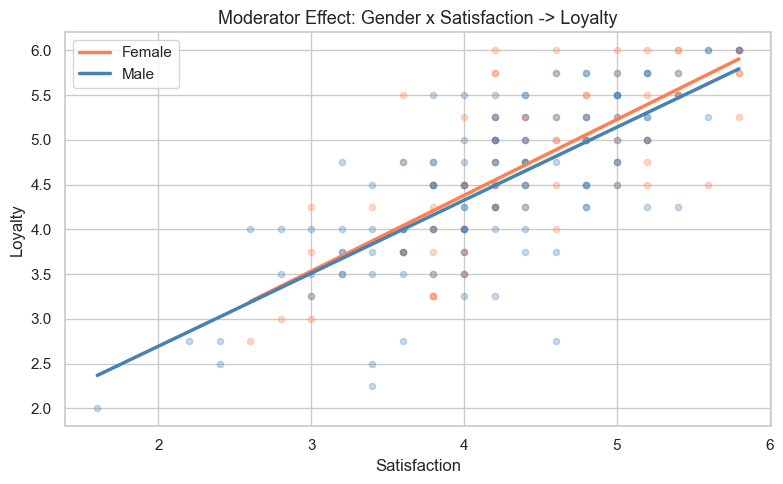

Parallel slopes -> no moderation  |  Diverging slopes -> moderation present


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

gender_map = {'Female': 'coral', 'Male': 'steelblue'}
for g_val, color in gender_map.items():
    group = df[df['Gender'] == g_val].dropna(subset=['Satisfaction', 'Loyalty'])
    x_range = np.linspace(group['Satisfaction'].min(), group['Satisfaction'].max(), 100)
    z = np.polyfit(group['Satisfaction'], group['Loyalty'], 1)
    ax.scatter(group['Satisfaction'], group['Loyalty'], alpha=0.3, color=color, s=20)
    ax.plot(x_range, np.polyval(z, x_range), color=color, linewidth=2.5, label=g_val)

ax.set_xlabel('Satisfaction', fontsize=12)
ax.set_ylabel('Loyalty', fontsize=12)
ax.set_title('Moderator Effect: Gender x Satisfaction -> Loyalty', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('Parallel slopes -> no moderation  |  Diverging slopes -> moderation present')

**How to read this output**: Each line represents one gender group's regression of Satisfaction on Loyalty. Parallel lines mean Gender does not change the strength of the relationship. Converging or diverging lines mean the relationship is stronger for one group than the other. Crossing lines indicate that the direction of the relationship reverses across groups.

---
## Summary

| Step | Analysis | Key Metrics |
|------|----------|-------------|
| 1 | Data Cleaning | Missing values, |z| > 3 outliers, Shapiro-Wilk, descriptive stats |
| 2 | Reliability | Cronbach's α ≥ 0.7 |
| 3 | Validity (EFA) | Factor loadings > 0.5, cross-loadings < 0.3 |
| 4 | Measurement (CFA) | CFI ≥ 0.95, RMSEA ≤ 0.06, SRMR ≤ 0.08; AVE > 0.5, CR > 0.7 |
| 5 | Correlation | Correlation matrix, Fornell-Larcker, VIF < 5 |
| 6a | Path Analysis | Structural β coefficients, overall fit |
| 6b | Mediation | Sobel z + Bootstrap 95% CI |
| 6c | Moderation | ΔR², interaction coefficient, interaction plot |